In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
import traceback
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

Dataset path or embeddings path is not set. Please check the .env configuration.


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: bird


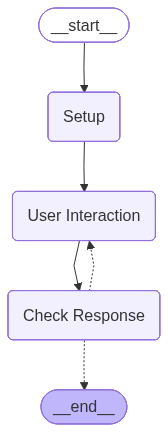

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
bird_error_exps = ["6", "14", "24", "28", "33", "34", "43"]
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    if database == "bird":
        
        if exp_id in bird_error_exps:
            continue
    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    try:
        # Invoca a avaliação
        eval_result = eval_graph.invoke(
            {
                "experiment": experiment,
                "max_retries": 2,
                "debug_mode": True,
                "model_version": model_version,
                "experiment_type": experiment_type,
            },
            {"recursion_limit": 200}
        )

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Salva resultado
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get(
                "experiment_config",
                {
                    "max_retries": 2,
                    "model_version": model_version,
                    "timestamp": datetime.now().isoformat(),
                    "experiment_type": experiment_type,
                }
            ),
            "experiment_eval": eval_result["experiment_eval"]
        })

    except Exception as e:
        print(f"\n Erro ao processar experimento {exp_id}: {e}")
        traceback.print_exc()

        # (Opcional) registra falha no arquivo de saída
        # evals.append({
        #     "experiment_id": exp_id,
        #     "experiment_config": {
        #         "model_version": model_version,
        #         "timestamp": datetime.now().isoformat(),
        #         "experiment_type": experiment_type,
        #     },
        #     "experiment_eval": None,
        #     "error": str(e)
        # })

    finally:
        # Atualiza o arquivo SEMPRE (sucesso ou erro)
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)

Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 7 já processado.
Pulando experimento 8 já processado.
Pulando experimento 9 já processado.
Pulando experimento 10 já processado.
Pulando experimento 11 já processado.
Pulando experimento 12 já processado.
Pulando experimento 13 já processado.
Pulando experimento 15 já processado.
Pulando experimento 16 já processado.
Pulando experimento 17 já processado.
Pulando experimento 18 já processado.
Pulando experimento 19 já processado.
Pulando experimento 20 já processado.
Pulando experimento 21 já processado.
Pulando experimento 22 já processado.
Pulando experimento 23 já processado.
Pulando experimento 25 já processado.
Pulando experimento 26 já processado.
Pulando experimento 29 já processado.
Pulando experimento 30 já processado.
Pulando experimento 31 já processado.
Pulando experimento 

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "Get the total points scored by each constructor.",
    "schema_linking": ["formula_1_constructors", "formula_1_results"],
    "answer": "The top constructors by points scored are Ferrari (7934.6 points), McLaren (5301.5 points), Red Bull (3750.5 points), Mercedes (3664.1 points), and Williams (3535 points). Many other constructors have scored fewer points, including some with zero.",
    "sql": "SELECT c.name AS constructor_name, SUM(r.points) AS total_points\nFROM formula_1_constructors c\nJOIN formula_1_results r ON c.constructorid = r.constructorid\nGROUP BY c.name\nORDER BY total_points DESC"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Get the total points scored by each constructor.",
    "schema_linking": ["formula_1_constructors", "formula_1_results"],
    "answer": "The top constructors by points scored are Ferrari (7934.6 points), McLaren

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


True cols: Index(['POINTS'], dtype='object')
Adj. True cols: Index([], dtype='object')
Predicted cols: Index(['CONSTRUCTOR_NAME', 'TOTAL_POINTS'], dtype='object')
Adj. Predicted cols: Index([], dtype='object')
[AI as JUDGE sql query correctness] Result: F with 0.9999993295729128 of confidence. And result metadata: {'token_usage': {'completion_tokens': 2, 'prompt_tokens': 415, 'total_tokens': 417, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_b54fe76834', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': 

...

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "What is the lowest position achieved by any constructor?",
    "schema_linking": ["formula_1_constructorstandings"],
    "answer": "The lowest position achieved by any constructor is position 1.",
    "sql": "SELECT MIN(position) AS lowest_position FROM formula_1_constructorstandings"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What is the lowest position achieved by any constructor?",
    "schema_linking": ["formula_1_constructorstandings"],
    "answer": "The lowest position achieved by any constructor is position 1.",
    "sql": "SELECT MIN(position) AS lowest_position FROM formula_1_constructorstandings"
}.

[INFO] Avaliando o resultado: {'input': 'What is the lowest position achieved by any constructor?', 'schema_linking': ['formula_1_constructorstandings'], 'answer': 'The lowest position achieved by any constructor is position 1.', 'sql': 'S

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects a

[INFO] O resultado da execução foi: {
    "input": "How many constructors have scored more than 10 points?",
    "schema_linking": ["formula_1_constructors", "formula_1_constructorresults"],
    "answer": "A total of 871 constructors have scored more than 10 points.",
    "sql": "SELECT COUNT( c.constructorid) AS constructor_count FROM formula_1_constructors c JOIN formula_1_constructorresults cr ON c.constructorid = cr.constructorid WHERE cr.points > 10;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "How many constructors have scored more than 10 points?",
    "schema_linking": ["formula_1_constructors", "formula_1_constructorresults"],
    "answer": "A total of 871 constructors have scored more than 10 points.",
    "sql": "SELECT COUNT( c.constructorid) AS constructor_count FROM formula_1_constructors c JOIN formula_1_constructorresults cr ON c.constructorid = cr.constructorid WHERE cr.points > 10

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
